In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind

df=pd.read_csv(r'C:\Users\keert\Downloads\medical-charges.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.shape

(1338, 7)

In [4]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
((df.isnull().sum())/len(df))*100

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [10]:
df=df.drop_duplicates(keep='first')

In [11]:
df.shape

(1337, 7)

In [12]:
for col in df.select_dtypes(include='object').columns:
    print(col,':',df[col].unique())

sex : ['female' 'male']
smoker : ['yes' 'no']
region : ['southwest' 'southeast' 'northwest' 'northeast']


In [13]:
for col in df.select_dtypes(include='object').columns:
    print(col,':',df[col].value_counts())

sex : sex
male      675
female    662
Name: count, dtype: int64
smoker : smoker
no     1063
yes     274
Name: count, dtype: int64
region : region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## Hypothesis Testing

The following statistical tests are performed:

- **Shapiro-Wilk Test** – Tests the normality assumption.
- **Levene's Test** – Tests the equality of variances.
- **Independent Two-Sample t-test** – Determines whether the mean insurance charges differ significantly between smokers and non-smokers.

In [14]:
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

In [15]:
from scipy.stats import shapiro, levene, ttest_ind

# 1. Normality check
stat1, p1 = shapiro(smoker_charges)
stat2, p2 = shapiro(nonsmoker_charges)
print('Smoker group normality p-value:', p1)
print('Non-smoker group normality p-value:', p2)

# 2. Equal variance check
lev_stat, lev_p = levene(smoker_charges, nonsmoker_charges)
print('Levene p-value:', lev_p)



Smoker group normality p-value: 3.6249900590074277e-09
Non-smoker group normality p-value: 1.5035032808411558e-28
Levene p-value: 1.670117565125241e-66


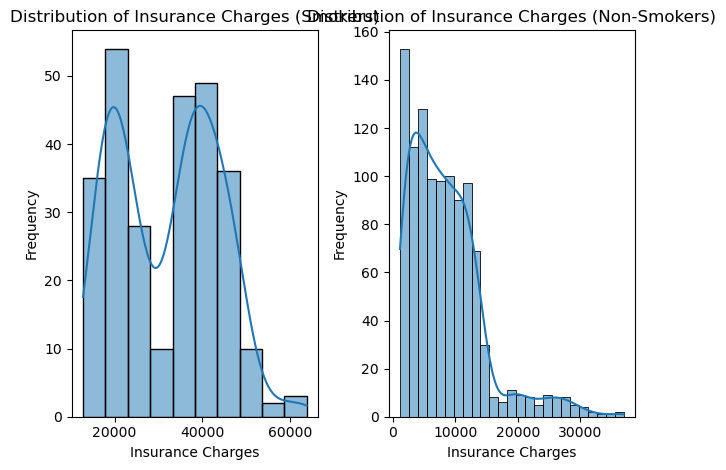

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots
fig, axes = plt.subplots(1, 2)

# Histogram + KDE for smokers
sns.histplot(smoker_charges,kde=True,ax=axes[0])
axes[0].set_title("Distribution of Insurance Charges (Smokers)")
axes[0].set_xlabel("Insurance Charges")
axes[0].set_ylabel("Frequency")

# Histogram + KDE for non-smokers
sns.histplot(nonsmoker_charges, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Insurance Charges (Non-Smokers)")
axes[1].set_xlabel("Insurance Charges")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Q-Q Plot: Non-Smoker Insurance Charges')

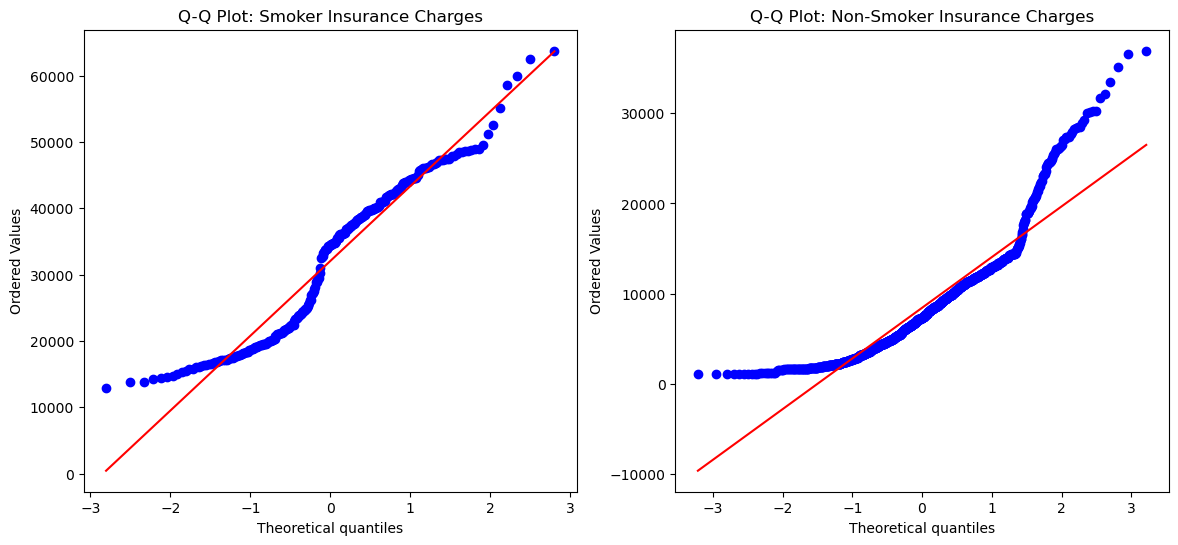

In [17]:
from scipy import stats
import matplotlib.pyplot as plt

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q plot for smokers
stats.probplot(smoker_charges, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Smoker Insurance Charges")

# Q-Q plot for non-smokers
stats.probplot(nonsmoker_charges, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Non-Smoker Insurance Charges")



In [18]:
# 3. t-test (using equal_var based on Levene's result)
equal_var_flag = lev_p >= 0.05   # True if variances are equal, False if not
t_stat, p_value = ttest_ind(smoker_charges, nonsmoker_charges, equal_var=equal_var_flag,alternative='greater')
print('t-statistic:', t_stat)
print('p-value:', p_value)
print('Used equal_var =', equal_var_flag)

t-statistic: 32.7423097372529
p-value: 3.1308603873638155e-103
Used equal_var = False


Text(0, 0.5, 'Insurance Charges')

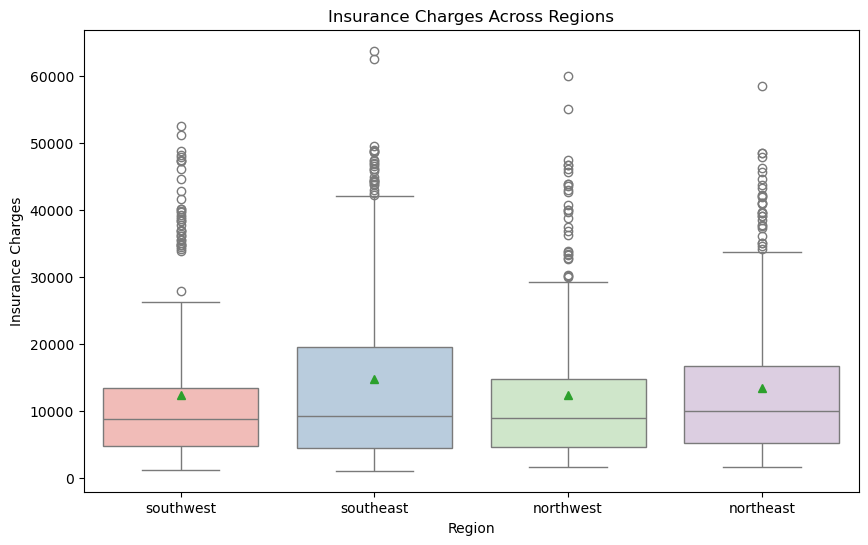

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='region',y='charges',hue='region',palette='Pastel1',legend=False,showmeans=True)
plt.title("Insurance Charges Across Regions")
plt.xlabel("Region")
plt.ylabel("Insurance Charges")

In [20]:
northeast=df[df['region']=='northeast']['charges']
northwest=df[df['region']=='northwest']['charges']
southeast=df[df['region']=='southeast']['charges']
southwest=df[df['region']=='southwest']['charges']



In [21]:
alpha=0.05
region={
     "Northeast": northeast,
    "Northwest": northwest,
    "Southeast": southeast,
    "Southwest": southwest
    }
for region,values in region.items():
    stat,p=shapiro(values)
    print(f"{region}")
    print(f"p-value:{p:.4e}")

Northeast
p-value:6.5524e-18
Northwest
p-value:4.6607e-19
Southeast
p-value:1.2326e-19
Southwest
p-value:2.0238e-20


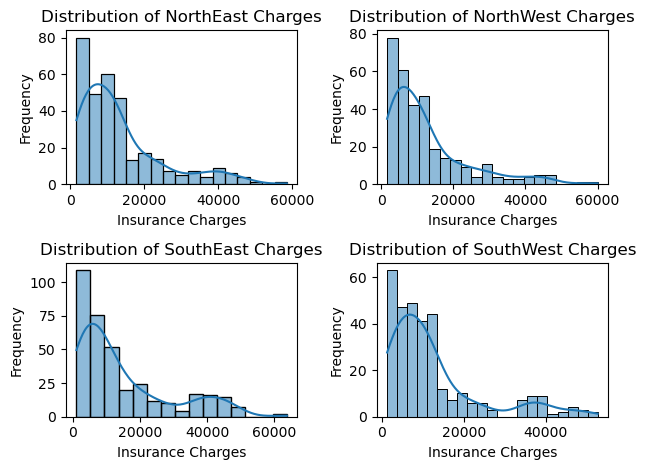

In [22]:
# Create figure with two subplots
fig, axes = plt.subplots(2, 2)
axes=axes.flatten()
# Histogram + KDE for smokers
sns.histplot(northeast,kde=True,ax=axes[0])
axes[0].set_title("Distribution of NorthEast Charges")
axes[0].set_xlabel("Insurance Charges")
axes[0].set_ylabel("Frequency")

# Histogram + KDE for non-smokers
sns.histplot(northwest, kde=True, ax=axes[1])
axes[1].set_title("Distribution of NorthWest Charges")
axes[1].set_xlabel("Insurance Charges")
axes[1].set_ylabel("Frequency")



sns.histplot(southeast,kde=True,ax=axes[2])
axes[2].set_title("Distribution of SouthEast Charges")
axes[2].set_xlabel("Insurance Charges")
axes[2].set_ylabel("Frequency")

# Histogram + KDE for non-smokers
sns.histplot(southwest, kde=True, ax=axes[3])
axes[3].set_title("Distribution of SouthWest Charges")
axes[3].set_xlabel("Insurance Charges")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Q-Q Plot: Southwest')

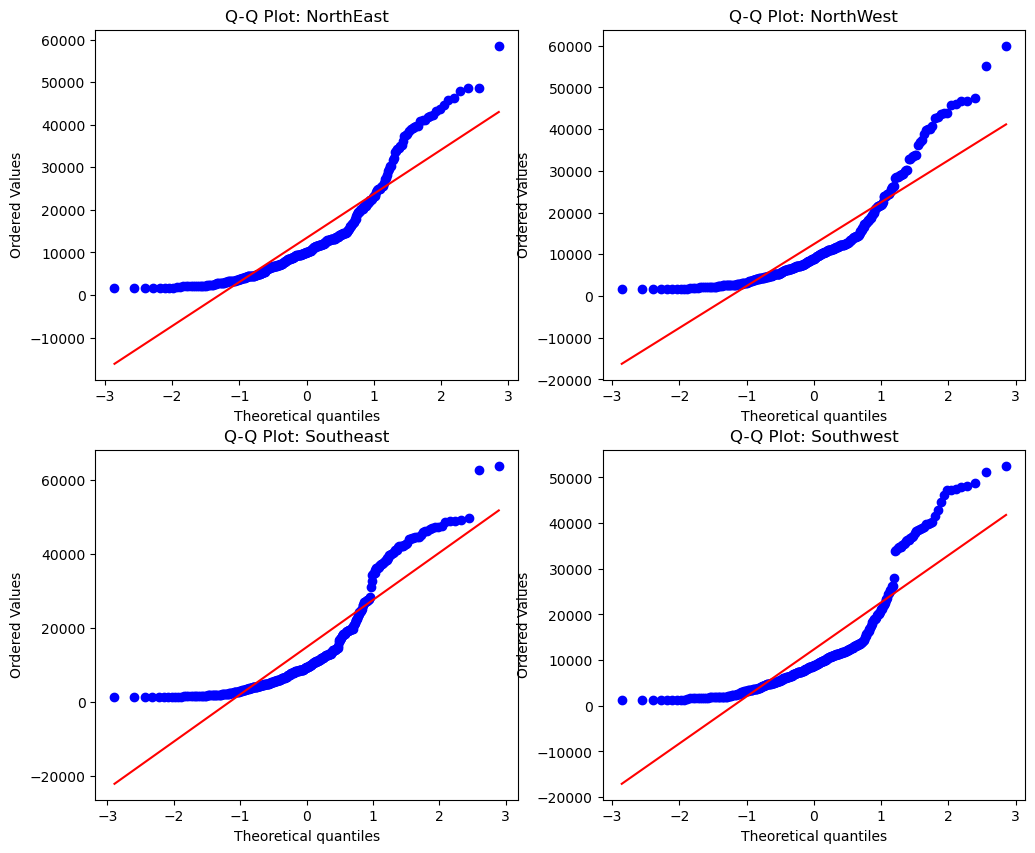

In [23]:
# Create figure with two subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes=axes.flatten()

# Q-Q plot for smokers
stats.probplot(northeast, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: NorthEast")

# Q-Q plot for non-smokers
stats.probplot(northwest, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: NorthWest")

stats.probplot(southeast, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot: Southeast")

# Q-Q plot for non-smokers
stats.probplot(southwest, dist="norm", plot=axes[3])
axes[3].set_title("Q-Q Plot: Southwest")


In [24]:
lev_stat, lev_p = levene(
    northeast,
    northwest,
    southeast,
    southwest
)


print("p-value:", lev_p)

p-value: 0.0008689544824002284


In [25]:
from scipy.stats import f_oneway
equal_var_flag = bool(lev_p >= 0.05)
print(equal_var_flag)


False


In [26]:
f_stat,p_value=f_oneway(northeast,northwest,southeast,southwest,equal_var=equal_var_flag)
print(p_value)

0.05348899434656477


In [27]:
x=df.drop(columns='charges')
y=df['charges']
x['sex']=x['sex'].map({'female':0,'male':1})
x['smoker']=x['smoker'].map({'yes':1,'no':0})
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,southwest
1,18,1,33.770,1,0,southeast
2,28,1,33.000,3,0,southeast
3,33,1,22.705,0,0,northwest
4,32,1,28.880,0,0,northwest


In [28]:
#one hot encode
x=pd.get_dummies(x,columns=['region'],drop_first=True,dtype=int)
x.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [29]:
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_
})

coef_df

,Feature,Coefficient
0,age,248.210720
1,sex,-101.542054
2,bmi,318.701441
3,children,533.009989
4,smoker,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


In [33]:
y_pred=lr.predict(x_test)

In [34]:
results=pd.DataFrame({"Actual":y_test,
                      "Prediction":y_pred})
results.head()

,Actual,Prediction
900,8688.85885,8143.693884
1064,5708.86700,5737.115683
1256,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657


In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [36]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 4177.05
MSE  : 35478020.68
RMSE : 5956.34
R²   : 0.8069


In [37]:
residuals=y_test-y_pred

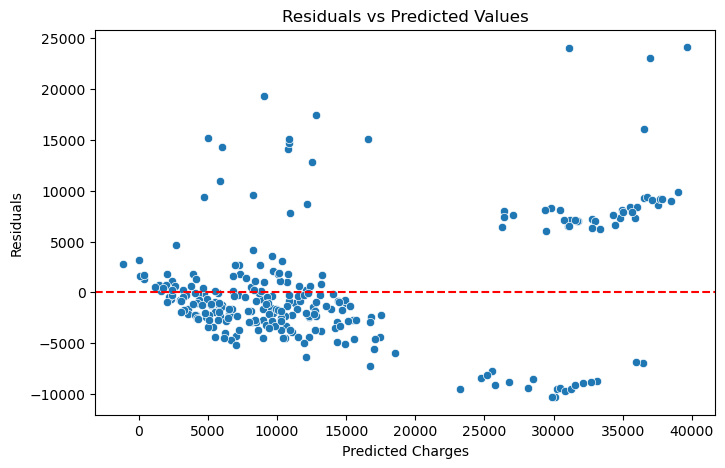

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

In [39]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 1.6968785669071645e-12


<Axes: xlabel='charges', ylabel='Count'>

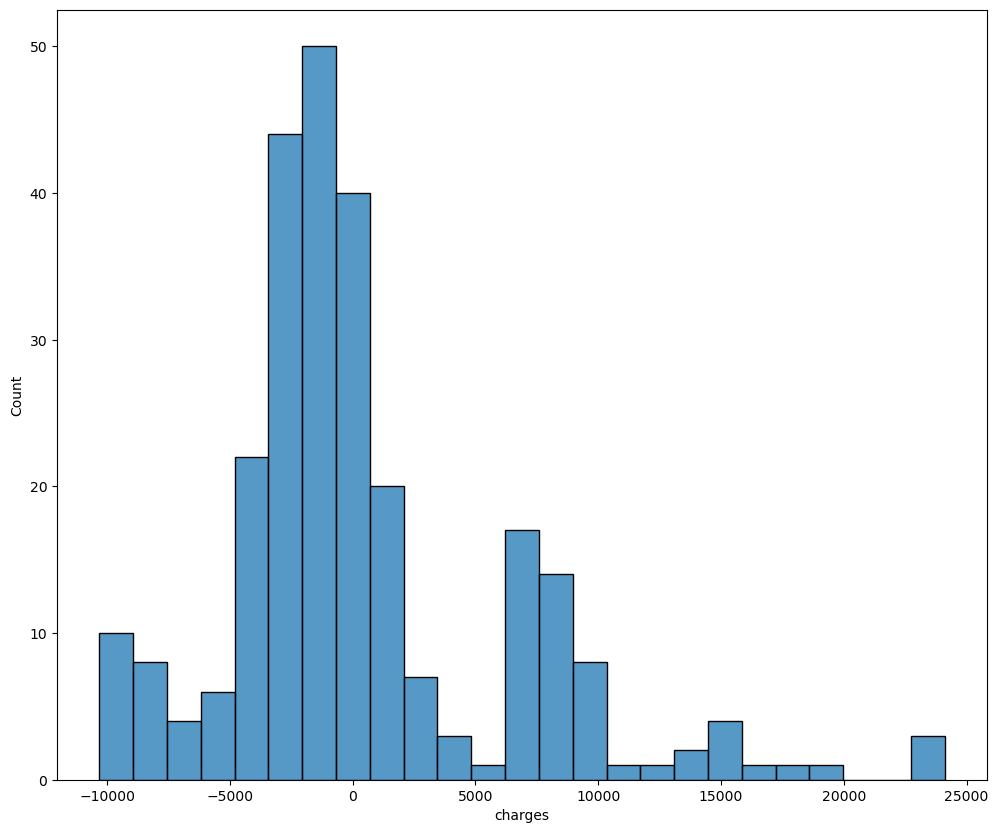

In [41]:
plt.figure(figsize=(12,10))
sns.histplot(residuals)

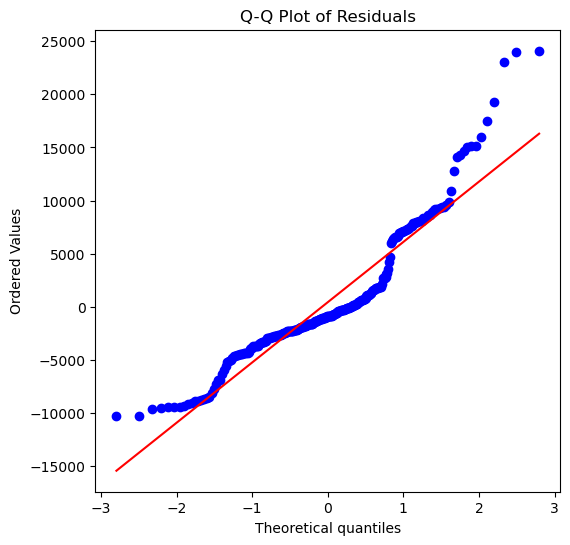

In [50]:
plt.figure(figsize=(6,6))
stats.probplot(residuals,dist='norm',plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = x_train.columns

vif["VIF"] = [
    variance_inflation_factor(x_train.values, i)
    for i in range(x_train.shape[1])
]

vif



,Feature,VIF
0,age,7.852117
1,sex,2.041788
2,bmi,11.778800
3,children,1.806171
4,smoker,1.255160
5,region_northwest,1.941491
6,region_southeast,2.290072
7,region_southwest,2.002452
